# U-Net 아키텍처 완벽 이해 실습

## 학습 목표
1. U-Net의 각 구성 요소를 직접 구현하며 이해하기
2. Encoder-Decoder 구조와 Skip Connection의 원리 파악
3. 실제 동작하는 U-Net 모델 만들고 테스트하기
4. pix2pix Generator로의 확장 이해하기



## 1️⃣ 환경 설정

필요한 라이브러리를 import합니다.
- `torch`: PyTorch 딥러닝 프레임워크
- `torchvision`: 이미지 처리 및 데이터셋
- `matplotlib`: 시각화

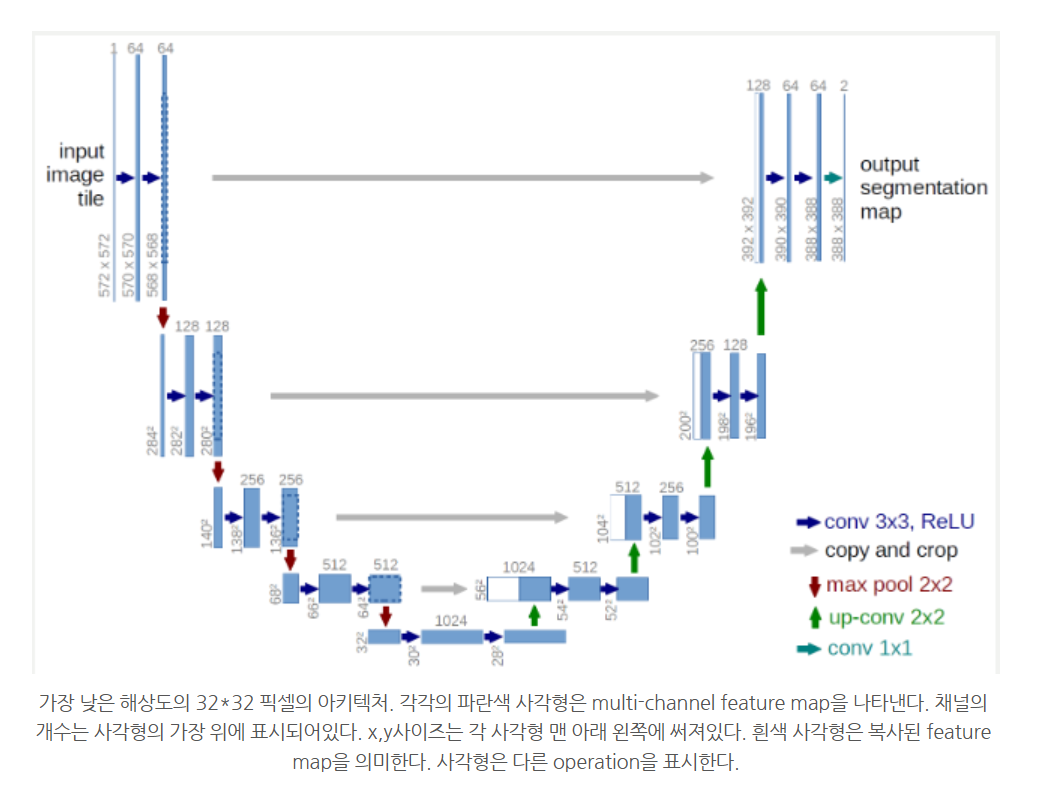

In [1]:
# 필수 라이브러리 import
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchsummary import summary

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 디바이스: {device}")
print(f"PyTorch 버전: {torch.__version__}")

사용 중인 디바이스: cuda
PyTorch 버전: 2.11.0+cu128


In [2]:
# torchsummary 설치 (모델 구조 시각화용)
!pip install torchsummary -q
print("설치 완료!")

설치 완료!


---

## 2️⃣ U-Net의 기본 블록: DoubleConv

U-Net의 **가장 기본이 되는 블록**입니다.

### 구조
```
입력 → Conv 3x3 → ReLU → Conv 3x3 → ReLU → 출력
```

### 특징
- 3x3 Convolution을 **2번 연속** 수행
- 각 Conv 후 ReLU 활성화 함수 적용
- `padding=1`로 크기 유지 (원본 논문과 차이점!)

### 왜 2번?
- 더 복잡한 특징을 학습할 수 있음
- 비선형성 증가 (ReLU 2번)

In [4]:
class DoubleConv(nn.Module):
    """
    U-Net의 기본 빌딩 블록

    구조: (Conv 3x3 → ReLU) x 2

    Args:
        in_channels (int): 입력 채널 수
        out_channels (int): 출력 채널 수
    """
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.double_conv = nn.Sequential(
            # 첫 번째 Convolution
            nn.Conv2d(
                in_channels,      # 입력 채널
                out_channels,     # 출력 채널
                kernel_size=3,    # 3x3 커널
                padding=1,        # 패딩 1 → 크기 유지 (중요!)
                bias=False        # BatchNorm 사용 시 bias 불필요
            ),
            nn.BatchNorm2d(out_channels),  # 배치 정규화
            nn.ReLU(inplace=True),         # ReLU 활성화

            # 두 번째 Convolution (구조 동일)
            nn.Conv2d(
                out_channels,     # 입력 = 첫 번째 출력
                out_channels,     # 출력 채널 유지
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        """
        순전파 (Forward pass)

        Args:
            x: 입력 텐서 [batch, in_channels, H, W]

        Returns:
            출력 텐서 [batch, out_channels, H, W]
        """
        return self.double_conv(x)

print("DoubleConv 클래스 정의 완료!")

DoubleConv 클래스 정의 완료!


### 🧪 DoubleConv 테스트

실제로 동작하는지 확인해봅시다!

In [5]:
# DoubleConv 블록 생성
# 입력 채널 3 (RGB) → 출력 채널 64
test_block = DoubleConv(in_channels=3, out_channels=64)

# 더미 입력 생성 (배치 1개, RGB 3채널, 256x256 크기)
dummy_input = torch.randn(1, 3, 256, 256)

# 순전파
output = test_block(dummy_input)

# 결과 출력

print("="*60)
print(f"입력 shape:  {dummy_input.shape}  <- [배치, 채널, 높이, 너비]")
print(f"출력 shape:  {output.shape}")
print("\n 관찰 포인트:")
print(f"   - 채널이 3 → 64로 증가")
print(f"   - 크기는 256x256으로 유지 (padding=1 덕분!)")
print("="*60)

입력 shape:  torch.Size([1, 3, 256, 256])  <- [배치, 채널, 높이, 너비]
출력 shape:  torch.Size([1, 64, 256, 256])

 관찰 포인트:
   - 채널이 3 → 64로 증가
   - 크기는 256x256으로 유지 (padding=1 덕분!)


---

## 3️⃣ Encoder 블록: Down (Downsampling)

U-Net의 **왼쪽 아래로 내려가는 경로**를 담당합니다.

### 구조
```
입력 → MaxPool 2x2 → DoubleConv → 출력
```

### 역할
- **해상도 감소**: 2x2 Max Pooling으로 크기를 절반으로
- **채널 증가**: DoubleConv로 더 많은 특징 추출
- **Receptive field 확장**: 더 넓은 영역을 볼 수 있게 됨

### 비유
- 줌 아웃(Zoom out)하면서 큰 그림을 보는 과정
- 세부사항은 줄고, 전체 맥락은 증가

In [7]:
class Down(nn.Module):
    """
    Downsampling 블록 (Encoder)

    구조: MaxPool 2x2 → DoubleConv
    결과: 해상도 1/2, 채널 증가

    Args:
        in_channels (int): 입력 채널 수
        out_channels (int): 출력 채널 수
    """
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()

        self.maxpool_conv = nn.Sequential(
            # MaxPooling으로 해상도 절반
            nn.MaxPool2d(kernel_size=2, stride=2),
            # DoubleConv로 특징 추출
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        """
        순전파

        Args:
            x: 입력 [batch, in_channels, H, W]

        Returns:
            출력 [batch, out_channels, H/2, W/2]
        """
        return self.maxpool_conv(x)


### 🧪 Down 블록 테스트

In [8]:
# Down 블록 생성
# 64 채널 → 128 채널
down_block = Down(in_channels=64, out_channels=128)

# 더미 입력 (256x256, 64채널)
dummy_input = torch.randn(1, 64, 256, 256)

# 순전파
output = down_block(dummy_input)


print(f"입력 shape:  {dummy_input.shape}")
print(f"출력 shape:  {output.shape}")
print("\n 관찰 포인트:")
print(f"   - 크기가 256x256 → 128x128 (절반!)")
print(f"   - 채널이 64 → 128 (2배!)")
print(f"   - 이것이 Encoder의 핵심 동작!")
print("="*60)

입력 shape:  torch.Size([1, 64, 256, 256])
출력 shape:  torch.Size([1, 128, 128, 128])

 관찰 포인트:
   - 크기가 256x256 → 128x128 (절반!)
   - 채널이 64 → 128 (2배!)
   - 이것이 Encoder의 핵심 동작!


---

## 4️⃣ Decoder 블록: Up (Upsampling)

U-Net의 **오른쪽 위로 올라가는 경로**를 담당합니다.

### 구조
```
x1 (Decoder) → Transpose Conv 2x2 (해상도 2배)
                      ↓
              x2 (Skip Connection)와 Concatenate
                      ↓
                  DoubleConv
```

### 핵심: Skip Connection
- Encoder의 **같은 해상도** 특징맵을 가져옴
- Channel 방향으로 **Concatenate** (덧셈 아님!)
- 세부 정보 복원의 핵심!

### 왜 Concatenate?
- **Add**: 정보가 섞임 → 일부 손실 가능
- **Concatenate**: 모든 정보 보존 → 네트워크가 선택

In [9]:
class Up(nn.Module):
    """
    Upsampling 블록 (Decoder)

    구조: Transpose Conv → Concatenate with skip → DoubleConv
    결과: 해상도 2배, 채널 감소

    Args:
        in_channels (int): 입력 채널 수 (Decoder에서 올라오는)
        out_channels (int): 출력 채널 수
    """
    def __init__(self, in_channels, out_channels):
        super(Up, self).__init__()

        # Transpose Convolution으로 해상도 2배 증가
        self.up = nn.ConvTranspose2d(
            in_channels,           # 입력 채널
            in_channels // 2,      # 출력 채널 (절반으로)
            kernel_size=2,         # 2x2 커널
            stride=2               # stride 2 → 해상도 2배
        )

        # Concatenate 후 DoubleConv
        # 입력 채널: in_channels (skip과 합쳐져서)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        """
        순전파

        Args:
            x1: Decoder에서 올라오는 특징맵 [batch, in_channels, H, W]
            x2: Skip connection (Encoder) [batch, in_channels//2, H*2, W*2]

        Returns:
            출력 [batch, out_channels, H*2, W*2]
        """
        # Step 1: x1을 upsampling (해상도 2배)
        x1 = self.up(x1)
        # 이제 x1과 x2의 해상도가 같음!

        # Step 2: x1과 x2를 Channel 방향으로 Concatenate
        # dim=1이 채널 차원 [batch, channel, H, W]
        x = torch.cat([x2, x1], dim=1)

        # Step 3: DoubleConv로 특징 추출
        return self.conv(x)



### 🧪 Up 블록 테스트 (Skip Connection 포함)

In [10]:
# Up 블록 생성
up_block = Up(in_channels=512, out_channels=256)

# 더미 입력 준비
# x1: Decoder에서 올라오는 작은 특징맵
x1 = torch.randn(1, 512, 32, 32)

# x2: Skip connection (Encoder의 같은 해상도)
x2 = torch.randn(1, 256, 64, 64)

# 순전파
output = up_block(x1, x2)


print("="*60)
print(f"x1 (Decoder):        {x1.shape}  <- 작은 특징맵")
print(f"x2 (Skip):           {x2.shape}  <- Encoder의 특징맵")
print(f"\n[처리 과정]")
print(f"1. x1 upsampling:    [1, 256, 64, 64]")
print(f"2. Concatenate:      [1, 512, 64, 64]  <- 256+256=512")
print(f"3. DoubleConv 후:    {output.shape}")
print("\n 관찰 포인트:")
print(f"   - 해상도가 32x32 → 64x64 (2배!)")
print(f"   - Skip connection으로 세부 정보 복원!")
print("="*60)

x1 (Decoder):        torch.Size([1, 512, 32, 32])  <- 작은 특징맵
x2 (Skip):           torch.Size([1, 256, 64, 64])  <- Encoder의 특징맵

[처리 과정]
1. x1 upsampling:    [1, 256, 64, 64]
2. Concatenate:      [1, 512, 64, 64]  <- 256+256=512
3. DoubleConv 후:    torch.Size([1, 256, 64, 64])

 관찰 포인트:
   - 해상도가 32x32 → 64x64 (2배!)
   - Skip connection으로 세부 정보 복원!


---

## 5️⃣ 완성! 전체 U-Net 모델

이제 모든 블록을 조합하여 **완전한 U-Net**을 만듭니다!

### 전체 구조
```
입력 (3채널, 256x256)
  ↓ DoubleConv
64채널 ----------------------→ (skip1)
  ↓ Down                          ↓
128채널 --------------------→ (skip2)
  ↓ Down                        ↓
256채널 ------------------→ (skip3)
  ↓ Down                      ↓
512채널 ----------------→ (skip4)
  ↓ Down                    ↓
1024채널 (Bottleneck)        ↓
  ↓ Up + skip4              ↓
512채널                      ↓
  ↓ Up + skip3             ↓
256채널                     ↓
  ↓ Up + skip2            ↓
128채널                    ↓
  ↓ Up + skip1           ↓
64채널
  ↓ Conv 1x1
출력 (n_classes채널, 256x256)
```

In [11]:
class UNet(nn.Module):
    """
    U-Net: Convolutional Networks for Biomedical Image Segmentation

    완전한 U-Net 아키텍처 구현
    - Encoder: 4단계 다운샘플링
    - Bottleneck: 가장 깊은 층
    - Decoder: 4단계 업샘플링 (Skip connections 포함)

    Args:
        n_channels (int): 입력 이미지 채널 수 (RGB=3, Grayscale=1)
        n_classes (int): 출력 클래스 수 (Segmentation 클래스 개수)
    """
    def __init__(self, n_channels=3, n_classes=2):
        super(UNet, self).__init__()

        # ==================== ENCODER (Contracting Path) ====================
        # 입력 처리 (초기 DoubleConv)
        self.inc = DoubleConv(n_channels, 64)

        # Encoder: 4단계 다운샘플링
        self.down1 = Down(64, 128)      # 64 → 128 channels
        self.down2 = Down(128, 256)     # 128 → 256 channels
        self.down3 = Down(256, 512)     # 256 → 512 channels
        self.down4 = Down(512, 1024)    # 512 → 1024 channels (Bottleneck으로)

        # ==================== DECODER (Expanding Path) ====================
        # Decoder: 4단계 업샘플링 (역순)
        self.up1 = Up(1024, 512)        # 1024 → 512 channels
        self.up2 = Up(512, 256)         # 512 → 256 channels
        self.up3 = Up(256, 128)         # 256 → 128 channels
        self.up4 = Up(128, 64)          # 128 → 64 channels

        # ==================== OUTPUT ====================
        # 최종 출력: 1x1 Convolution으로 클래스 수만큼 채널 변환
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        """
        순전파 (Forward pass)

        Args:
            x: 입력 이미지 [batch, n_channels, H, W]

        Returns:
            출력 segmentation map [batch, n_classes, H, W]
        """
        # ==================== ENCODER ====================
        # Skip connection용 특징맵 저장하면서 내려감

        x1 = self.inc(x)        # [batch, 64, H, W]
        x2 = self.down1(x1)     # [batch, 128, H/2, W/2]
        x3 = self.down2(x2)     # [batch, 256, H/4, W/4]
        x4 = self.down3(x3)     # [batch, 512, H/8, W/8]
        x5 = self.down4(x4)     # [batch, 1024, H/16, W/16] <- Bottleneck!

        # ==================== DECODER ====================
        # Skip connection과 결합하면서 올라감 (역순)

        x = self.up1(x5, x4)    # x5 + skip(x4) → [batch, 512, H/8, W/8]
        x = self.up2(x, x3)     # x + skip(x3)   → [batch, 256, H/4, W/4]
        x = self.up3(x, x2)     # x + skip(x2)   → [batch, 128, H/2, W/2]
        x = self.up4(x, x1)     # x + skip(x1)   → [batch, 64, H, W]

        # ==================== OUTPUT ====================
        logits = self.outc(x)   # [batch, n_classes, H, W]

        return logits



---

## 6️⃣ U-Net 모델 생성 및 테스트

실제로 작동하는지 확인해봅시다!

In [12]:
# U-Net 모델 생성
# 입력: RGB 이미지 (3채널)
# 출력: 2-class segmentation (배경 vs 객체)
model = UNet(n_channels=3, n_classes=2)

# GPU로 이동 (사용 가능한 경우)
model = model.to(device)

### 📊 모델 요약 확인

전체 네트워크 구조와 파라미터 수를 확인합니다.

In [13]:
from torchsummary import summary

# 모델 구조 요약 (입력: 3채널, 256x256)
print("="*60)
print("U-Net 모델 구조 요약")
print("="*60)
summary(model, input_size=(3, 256, 256))

U-Net 모델 구조 요약
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,728
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,864
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              ReLU-6         [-1, 64, 256, 256]               0
        DoubleConv-7         [-1, 64, 256, 256]               0
         MaxPool2d-8         [-1, 64, 128, 128]               0
            Conv2d-9        [-1, 128, 128, 128]          73,728
      BatchNorm2d-10        [-1, 128, 128, 128]             256
             ReLU-11        [-1, 128, 128, 128]               0
           Conv2d-12        [-1, 128, 128, 128]         147,456
      BatchNorm2d-13        [-1, 128, 128, 128]             256
             ReLU-14    

### 🧪 더미 데이터로 Forward Pass 테스트

In [14]:
# 더미 입력 생성
# 배치 크기 4, RGB 3채널, 256x256 이미지
dummy_input = torch.randn(4, 3, 256, 256).to(device)

# 모델을 평가 모드로 설정
model.eval()

# Forward pass (추론)
with torch.no_grad():
    output = model(dummy_input)


print(f"입력 shape:  {dummy_input.shape}")
print(f"           ↳ [배치, 채널, 높이, 너비]")
print(f"\n출력 shape:  {output.shape}")
print(f"           ↳ [배치, 클래스, 높이, 너비]")
print(f"\n💡 해석:")
print(f"   - 각 픽셀마다 2개 클래스에 대한 점수(logit) 생성")
print(f"   - 입출력 크기 동일! (256x256 유지)")
print(f"   - 이것이 Semantic Segmentation의 핵심!")
print("="*60)

입력 shape:  torch.Size([4, 3, 256, 256])
           ↳ [배치, 채널, 높이, 너비]

출력 shape:  torch.Size([4, 2, 256, 256])
           ↳ [배치, 클래스, 높이, 너비]

💡 해석:
   - 각 픽셀마다 2개 클래스에 대한 점수(logit) 생성
   - 입출력 크기 동일! (256x256 유지)
   - 이것이 Semantic Segmentation의 핵심!


---

## 7️⃣ 각 단계별 특징맵 크기 확인

U-Net의 **Encoder와 Decoder에서 크기가 어떻게 변하는지** 직접 확인해봅시다!

In [15]:
# 테스트용 간단한 입력
test_input = torch.randn(1, 3, 256, 256).to(device)

# 각 단계별 출력을 저장할 리스트
encoder_outputs = []
decoder_outputs = []

# Forward pass하면서 중간 출력 저장
with torch.no_grad():
    # ==================== ENCODER ====================
    x1 = model.inc(test_input)
    encoder_outputs.append(('Initial Conv', x1.shape))

    x2 = model.down1(x1)
    encoder_outputs.append(('Down 1', x2.shape))

    x3 = model.down2(x2)
    encoder_outputs.append(('Down 2', x3.shape))

    x4 = model.down3(x3)
    encoder_outputs.append(('Down 3', x4.shape))

    x5 = model.down4(x4)
    encoder_outputs.append(('Bottleneck', x5.shape))

    # ==================== DECODER ====================
    x = model.up1(x5, x4)
    decoder_outputs.append(('Up 1', x.shape))

    x = model.up2(x, x3)
    decoder_outputs.append(('Up 2', x.shape))

    x = model.up3(x, x2)
    decoder_outputs.append(('Up 3', x.shape))

    x = model.up4(x, x1)
    decoder_outputs.append(('Up 4', x.shape))

    output = model.outc(x)
    decoder_outputs.append(('Output', output.shape))

# 결과 출력
print("="*70)
print("U-Net 각 단계별 특징맵 크기 변화")
print("="*70)

print("\nENCODER (Contracting Path) - 아래로 내려가며 압축")
print("-"*70)
for name, shape in encoder_outputs:
    b, c, h, w = shape
    print(f"{name:20s} → [{b}, {c:4d}, {h:3d}, {w:3d}]")

print("\nDECODER (Expanding Path) - 위로 올라가며 복원")
print("-"*70)
for name, shape in decoder_outputs:
    b, c, h, w = shape
    print(f"{name:20s} → [{b}, {c:4d}, {h:3d}, {w:3d}]")

print("\n관찰 포인트:")
print("   1. Encoder: 해상도 ↓, 채널 ↑ (추상화)")
print("   2. Bottleneck: 가장 작은 해상도 (16x16), 가장 많은 채널 (1024)")
print("   3. Decoder: 해상도 ↑, 채널 ↓ (구체화)")
print("   4. 대칭 구조: Down 4단계 ↔ Up 4단계")
print("="*70)

U-Net 각 단계별 특징맵 크기 변화

ENCODER (Contracting Path) - 아래로 내려가며 압축
----------------------------------------------------------------------
Initial Conv         → [1,   64, 256, 256]
Down 1               → [1,  128, 128, 128]
Down 2               → [1,  256,  64,  64]
Down 3               → [1,  512,  32,  32]
Bottleneck           → [1, 1024,  16,  16]

DECODER (Expanding Path) - 위로 올라가며 복원
----------------------------------------------------------------------
Up 1                 → [1,  512,  32,  32]
Up 2                 → [1,  256,  64,  64]
Up 3                 → [1,  128, 128, 128]
Up 4                 → [1,   64, 256, 256]
Output               → [1,    2, 256, 256]

관찰 포인트:
   1. Encoder: 해상도 ↓, 채널 ↑ (추상화)
   2. Bottleneck: 가장 작은 해상도 (16x16), 가장 많은 채널 (1024)
   3. Decoder: 해상도 ↑, 채널 ↓ (구체화)
   4. 대칭 구조: Down 4단계 ↔ Up 4단계


---

## 8️⃣ Skip Connection 시각화

Skip connection이 **어떻게 정보를 전달**하는지 확인해봅시다!

In [16]:
# Skip connection 정보 정리
skip_connections = [
    {'name': 'Skip 1', 'encoder': 'x1 (64, 256x256)', 'decoder': 'Up 4', 'purpose': '가장 세밀한 디테일'},
    {'name': 'Skip 2', 'encoder': 'x2 (128, 128x128)', 'decoder': 'Up 3', 'purpose': '중간 디테일'},
    {'name': 'Skip 3', 'encoder': 'x3 (256, 64x64)', 'decoder': 'Up 2', 'purpose': '구조 정보'},
    {'name': 'Skip 4', 'encoder': 'x4 (512, 32x32)', 'decoder': 'Up 1', 'purpose': '고수준 특징'},
]

print("="*80)
print("U-Net Skip Connections 정보")
print("="*80)
print(f"{'Skip':10s} {'Encoder 출력':25s} {'→':5s} {'Decoder 입력':15s} {'역할':20s}")
print("-"*80)

for skip in skip_connections:
    print(f"{skip['name']:10s} {skip['encoder']:25s} {'→':5s} {skip['decoder']:15s} {skip['purpose']:20s}")

print("\n Skip Connection의 마법:")
print("   - Encoder: '무엇'인지 파악 (맥락)")
print("   - Skip: '어디'에 있는지 전달 (위치)")
print("   - Decoder: 두 정보를 결합하여 정확한 분할")
print("\n   비유: 숲(전체)과 나무(디테일)를 동시에 보기!")
print("="*80)

U-Net Skip Connections 정보
Skip       Encoder 출력                →     Decoder 입력      역할                  
--------------------------------------------------------------------------------
Skip 1     x1 (64, 256x256)          →     Up 4            가장 세밀한 디테일          
Skip 2     x2 (128, 128x128)         →     Up 3            중간 디테일              
Skip 3     x3 (256, 64x64)           →     Up 2            구조 정보               
Skip 4     x4 (512, 32x32)           →     Up 1            고수준 특징              

 Skip Connection의 마법:
   - Encoder: '무엇'인지 파악 (맥락)
   - Skip: '어디'에 있는지 전달 (위치)
   - Decoder: 두 정보를 결합하여 정확한 분할

   비유: 숲(전체)과 나무(디테일)를 동시에 보기!


---

## 9️⃣ pix2pix Generator로 변환

U-Net을 **pix2pix의 Generator**로 변환하는 방법을 알아봅시다!

### 차이점
1. **출력 채널**: n_classes → 3 (RGB 이미지)
2. **활성화 함수**: 없음 → Tanh ([-1, 1] 범위)
3. **목적**: Segmentation → Image Generation

In [17]:
class UNetGenerator(nn.Module):
    """
    pix2pix용 U-Net Generator

    기본 U-Net과의 차이점:
    - 출력: Segmentation map → RGB 이미지
    - 활성화: 없음 → Tanh

    Args:
        n_channels (int): 입력 이미지 채널 수
    """
    def __init__(self, n_channels=3):
        super(UNetGenerator, self).__init__()

        # ==================== ENCODER ====================
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        # ==================== DECODER ====================
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        # ==================== OUTPUT (pix2pix용) ====================
        # RGB 이미지 생성 + Tanh 활성화
        self.outc = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=1),  # 3채널 (RGB)
            nn.Tanh()  # [-1, 1] 범위로 정규화
        )

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        # Output: RGB 이미지
        return self.outc(x)

### 🧪 pix2pix Generator 테스트

In [18]:
# pix2pix Generator 생성
generator = UNetGenerator(n_channels=3).to(device)

# 더미 입력 (예: Sketch 이미지)
sketch = torch.randn(1, 3, 256, 256).to(device)

# 이미지 생성
with torch.no_grad():
    generated_photo = generator(sketch)


print(f"입력 (Sketch):       {sketch.shape}")
print(f"출력 (Photo):        {generated_photo.shape}")
print(f"\n출력 값 범위:        [{generated_photo.min():.2f}, {generated_photo.max():.2f}]")
print(f"                     ↳ Tanh 덕분에 [-1, 1] 범위!")
print("\n pix2pix 응용 예시:")
print("   - Sketch → Photo")
print("   - Day → Night")
print("   - Satellite → Map")
print("   - Edges → Cats ")
print("="*60)

입력 (Sketch):       torch.Size([1, 3, 256, 256])
출력 (Photo):        torch.Size([1, 3, 256, 256])

출력 값 범위:        [-0.97, 0.92]
                     ↳ Tanh 덕분에 [-1, 1] 범위!

 pix2pix 응용 예시:
   - Sketch → Photo
   - Day → Night
   - Satellite → Map
   - Edges → Cats 


---

## 🔟 파라미터 수 비교

U-Net vs pix2pix Generator의 차이를 확인해봅시다.

In [19]:
def count_parameters(model):
    """모델의 학습 가능한 파라미터 수 계산"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 두 모델의 파라미터 수 계산
unet_params = count_parameters(model)
generator_params = count_parameters(generator)

print("="*60)
print("모델 파라미터 비교")
print("="*60)
print(f"U-Net (Segmentation):     {unet_params:,} 파라미터")
print(f"pix2pix Generator:        {generator_params:,} 파라미터")
print(f"\n차이:                     {abs(unet_params - generator_params):,}")
print("\n거의 동일! 출력층만 다름:")
print("   - U-Net: Conv 1x1 (64→2)")
print("   - pix2pix: Conv 1x1 (64→3) + Tanh")
print("="*60)

모델 파라미터 비교
U-Net (Segmentation):     31,037,698 파라미터
pix2pix Generator:        31,037,763 파라미터

차이:                     65

거의 동일! 출력층만 다름:
   - U-Net: Conv 1x1 (64→2)
   - pix2pix: Conv 1x1 (64→3) + Tanh


---

## 1️⃣1️⃣ 원본 논문 vs 실용적 구현 비교

우리가 구현한 버전과 **원본 논문의 차이점**을 정리합니다.

In [20]:
print("="*80)
print("원본 U-Net 논문 vs 실용적 구현 비교")
print("="*80)

comparison = [
    ('특징', '원본 논문 (2015)', '우리 구현 (실용적)'),
    ('-'*15, '-'*30, '-'*30),
    ('Padding', 'padding=0 (Valid)', 'padding=1 (Same)'),
    ('입출력 크기', '572x572 → 388x388', '256x256 → 256x256'),
    ('Batch Norm', '없음', '있음 (성능 향상)'),
    ('Overlap-tile', '사용 (큰 이미지 처리)', '불필요 (크기 유지)'),
    ('Crop', '필요 (크기 맞추기)', '불필요 (같은 크기)'),
    ('구현 난이도', '어려움', '쉬움'),
    ('실용성', '연구용', '실무용'),
]

for row in comparison:
    print(f"{row[0]:20s} | {row[1]:30s} | {row[2]:30s}")

print("\n핵심 차이: padding=1의 중요성")
print("   - 원본: 크기 감소 → Overlap-tile 전략 필요")
print("   - 우리: 크기 유지 → 구현 간단, 메모리 효율적")
print("   - 성능 차이는 거의 없음!")
print("="*80)

원본 U-Net 논문 vs 실용적 구현 비교
특징                   | 원본 논문 (2015)                   | 우리 구현 (실용적)                   
---------------      | ------------------------------ | ------------------------------
Padding              | padding=0 (Valid)              | padding=1 (Same)              
입출력 크기               | 572x572 → 388x388              | 256x256 → 256x256             
Batch Norm           | 없음                             | 있음 (성능 향상)                    
Overlap-tile         | 사용 (큰 이미지 처리)                  | 불필요 (크기 유지)                   
Crop                 | 필요 (크기 맞추기)                    | 불필요 (같은 크기)                   
구현 난이도               | 어려움                            | 쉬움                            
실용성                  | 연구용                            | 실무용                           

핵심 차이: padding=1의 중요성
   - 원본: 크기 감소 → Overlap-tile 전략 필요
   - 우리: 크기 유지 → 구현 간단, 메모리 효율적
   - 성능 차이는 거의 없음!


---

## 1️⃣2️⃣ 실전 팁: 메모리 최적화

U-Net은 메모리를 많이 사용합니다. 최적화 방법을 알아봅시다.

In [21]:
print("="*80)
print("U-Net 메모리 최적화 전략")
print("="*80)

tips = [
    ("1. Batch Size 줄이기", "8 → 4 → 2 → 1", "가장 효과적!"),
    ("2. 입력 크기 줄이기", "512x512 → 256x256", "성능 약간 감소"),
    ("3. 채널 수 줄이기", "64, 128, 256... → 32, 64, 128...", "경량화 모델"),
    ("4. Mixed Precision", "FP32 → FP16", "메모리 절반, 속도 2배"),
    ("5. Gradient Checkpointing", "중간 특징맵 재계산", "속도↓ 메모리↑"),
]

print(f"{'전략':30s} {'방법':30s} {'효과':20s}")
print("-"*80)
for tip, method, effect in tips:
    print(f"{tip:30s} {method:30s} {effect:20s}")

print("\n메모리 부족 에러 발생 시:")
print("   1. 먼저 batch_size를 줄여보세요")
print("   2. 그래도 안 되면 이미지 크기를 줄이세요")
print("   3. Colab Pro 사용 고려 (GPU 메모리 증가)")
print("="*80)

U-Net 메모리 최적화 전략
전략                             방법                             효과                  
--------------------------------------------------------------------------------
1. Batch Size 줄이기              8 → 4 → 2 → 1                  가장 효과적!             
2. 입력 크기 줄이기                   512x512 → 256x256              성능 약간 감소            
3. 채널 수 줄이기                    64, 128, 256... → 32, 64, 128... 경량화 모델              
4. Mixed Precision             FP32 → FP16                    메모리 절반, 속도 2배       
5. Gradient Checkpointing      중간 특징맵 재계산                     속도↓ 메모리↑            

메모리 부족 에러 발생 시:
   1. 먼저 batch_size를 줄여보세요
   2. 그래도 안 되면 이미지 크기를 줄이세요
   3. Colab Pro 사용 고려 (GPU 메모리 증가)


---

## 1️⃣3️⃣ 요약 및 핵심 포인트

지금까지 배운 내용을 정리합니다!

In [22]:
print("="*80)
print("U-Net 핵심 요약")
print("="*80)

print("\nU-Net의 3가지 핵심 구성 요소:")
print("   ┌─ Encoder (Contracting Path)")
print("   │  └─ 해상도 ↓, 채널 ↑ → 추상적 특징 학습")
print("   │")
print("   ├─ Skip Connections")
print("   │  └─ Encoder의 디테일을 Decoder로 전달")
print("   │")
print("   └─ Decoder (Expanding Path)")
print("      └─ 해상도 ↑, 채널 ↓ → 원본 크기 복원")

print("\nSkip Connection이 중요한 이유:")
print("   • Encoder: '무엇'인지 파악 (What)")
print("   • Skip: '어디'에 있는지 전달 (Where)")
print("   • Decoder: 정확한 픽셀 단위 복원")

print("\nU-Net → pix2pix 변환:")
print("   • 출력층만 변경: n_classes → 3 (RGB)")
print("   • Tanh 활성화 추가: [-1, 1] 범위")
print("   • 용도 변경: Segmentation → Image Generation")

print("\n실용적 개선사항:")
print("   • padding=1로 크기 유지")
print("   • Batch Normalization 추가")
print("   • 구현 단순화")

print("\n5응용 분야:")
print("   • 의료 영상 분석 (원래 목적)")
print("   • 위성사진 분석")
print("   • pix2pix (Image-to-Image Translation)")
print("   • 객체 분할")
print("   • 스타일 변환")



U-Net 핵심 요약

U-Net의 3가지 핵심 구성 요소:
   ┌─ Encoder (Contracting Path)
   │  └─ 해상도 ↓, 채널 ↑ → 추상적 특징 학습
   │
   ├─ Skip Connections
   │  └─ Encoder의 디테일을 Decoder로 전달
   │
   └─ Decoder (Expanding Path)
      └─ 해상도 ↑, 채널 ↓ → 원본 크기 복원

Skip Connection이 중요한 이유:
   • Encoder: '무엇'인지 파악 (What)
   • Skip: '어디'에 있는지 전달 (Where)
   • Decoder: 정확한 픽셀 단위 복원

U-Net → pix2pix 변환:
   • 출력층만 변경: n_classes → 3 (RGB)
   • Tanh 활성화 추가: [-1, 1] 범위
   • 용도 변경: Segmentation → Image Generation

실용적 개선사항:
   • padding=1로 크기 유지
   • Batch Normalization 추가
   • 구현 단순화

5응용 분야:
   • 의료 영상 분석 (원래 목적)
   • 위성사진 분석
   • pix2pix (Image-to-Image Translation)
   • 객체 분할
   • 스타일 변환


---

## 1️⃣4️⃣ 다음 단계: pix2pix로 가는 길

이제 pix2pix를 배울 준비가 되었습니다!

In [ ]:
print("="*80)
print(" pix2pix 학습 로드맵")
print("="*80)

print("\n지금까지 완료:")
print("   [✓] U-Net 구조 이해")
print("   [✓] Encoder-Decoder 구조")
print("   [✓] Skip Connection 원리")
print("   [✓] PyTorch 구현")



 pix2pix 학습 로드맵

지금까지 완료:
   [✓] U-Net 구조 이해
   [✓] Encoder-Decoder 구조
   [✓] Skip Connection 원리
   [✓] PyTorch 구현




### 자주 묻는 질문

**Q1: 왜 Concatenate이지 Add가 아닌가요?**
- A: Add는 정보가 섞이면서 일부 손실 가능. Concatenate는 모든 정보를 보존하여 네트워크가 스스로 선택하게 함.

**Q2: Batch Normalization은 왜 추가했나요?**
- A: 학습 안정화 및 성능 향상. 원본 논문에는 없지만 실용적으로 거의 항상 사용.

**Q3: 메모리가 부족하면?**
- A: Batch size 줄이기 → 이미지 크기 줄이기 → 채널 수 줄이기 순서로 시도.

**Q4: pix2pix랑 뭐가 다른가요?**
- A: U-Net은 Generator만. pix2pix는 U-Net (Generator) + PatchGAN (Discriminator).

### 추가 학습 자료

- **원본 논문**: [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://arxiv.org/abs/1505.04597)
- **pix2pix 논문**: [Image-to-Image Translation with Conditional Adversarial Networks](https://arxiv.org/abs/1611.07004)
- **PyTorch Tutorial**: https://pytorch.org/tutorials/

